# June 2025 European Heatwave Reforecast

The **June 2025 European heatwave** was the most intense heatwave of 2025, reaching its peak between 28 June and 2 July. This notebook runs a single AIFS reforecast initialised at the **heatwave onset (2025-06-20 00 UTC)** with a 240 h (10-day) lead time, then benchmarks the outputs against MeteoSwiss station observations in Switzerland using [stationbench](https://github.com/juaAI/stationbench).

Forecasting skill is assessed separately for the **medium range (days 1–7)** and the **extended range (days 7–10)**, following the lead-time stratification used in ECMWF verification. We conclude by assessing the ERA5-station biases to highlight the importance of validating against station observations.

In [ ]:
import datetime as dt
import os
import pathlib

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import stationbench
import xarray as xr
import zarr
from stationbench.utils import regions

from aifs_modal_demo import ingest, tasks
from aifs_modal_demo.app import app, run_forecast

## Set up

In [ ]:
# experiment label
experiment = "heatwave-2025-jun"

# forecast window: init at heatwave onset for a clean 10-day medium/extended-range eval
start_date = dt.datetime(2025, 6, 20, 0, tzinfo=dt.UTC)
lead_time = 240  # in hours, i.e., until 2025-06-30 00 UTC
end_date = start_date + dt.timedelta(hours=lead_time)
print(f"Experiment : {experiment}")
print(f"Start      : {start_date}")
print(f"End        : {end_date}  (T+{lead_time} h)")

# modal storage
storage_bucket = "aifs-modal"
initial_conditions_prefix = "aifs-initial-conditions"
initial_conditions_branch = "main"
outputs_prefix = "aifs-outputs"
outputs_branch = experiment

# stationbench
region = "switzerland"
lat_slice = (44.5, 48.5)
lon_slice = (4.5, 11.5)
stationbench_dir = pathlib.Path("../data/stationbench")
stations_filepath = stationbench_dir / f"{experiment}-stations.nc"
era5_filepath = stationbench_dir / f"{experiment}-era5.nc"

# viz
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

Experiment : heatwave-2025-jun
Start      : 2025-06-20 00:00:00+00:00
End        : 2025-06-30 00:00:00+00:00  (T+240 h)


## 1. Ingesting initial conditions

In [ ]:
initial_conditions_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=initial_conditions_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
initial_conditions_repo = icechunk.Repository.open_or_create(initial_conditions_storage)

for date in [start_date - dt.timedelta(hours=6), start_date]:
    ingest.ensure_date_ingested(
        date, initial_conditions_repo, branch=initial_conditions_branch
    )

  2026-03-11T14:27:42.315744Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773200802324/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121

Initial conditions already ingested for 2025-06-19T18:00:00+00:00 (group: 2025-06-19/18z); skipping
Initial conditions already ingested for 2025-06-20T00:00:00+00:00 (group: 2025-06-20/00z); skipping


## 2. Running the heatwave reforecast on Modal

First of all, we will check that we have not run this same (deterministic) forecast before to avoid re-running it (note that the modal app already avoids re-running existing forecasts however we can further avoid spinning up an ephemeral app by checking the existing forecast outputs):

In [ ]:
# forecast outputs icechunk session
outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
outputs_repo = icechunk.Repository.open(outputs_storage)

# check whether the branch and forecast group already exist
forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
try:
    outputs_session = outputs_repo.readonly_session(outputs_branch)
    forecast_exists = forecast_group in zarr.open_group(outputs_session.store, mode="r")
except icechunk.IcechunkError:
    forecast_exists = False  # branch doesn't exist yet

if not forecast_exists:
    # with modal.enable_output():  # uncomment for live logs
    with app.run():
        run_forecast.remote(
            start_date,
            storage_bucket,
            lead_time=lead_time,
            initial_conditions_prefix=initial_conditions_prefix,
            initial_conditions_branch=initial_conditions_branch,
            outputs_prefix=outputs_prefix,
            outputs_branch=outputs_branch,
            # surface variables only — no pressure levels needed for stationbench
            include_pressure_levels=False,
        )
    outputs_session = outputs_repo.readonly_session(outputs_branch)
else:
    print(f"Forecast already exists for {forecast_group}; skipping")

  2026-03-11T14:27:42.674438Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773200802324/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121

Forecast already exists for 2025-06-20/00z; skipping


## 3. Loading forecast outputs

We now read the forecast outputs for the relevant forecast group (initialization time) from icechunk into an xarray dataset:

In [ ]:
forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
forecast_ds = xr.open_dataset(
    outputs_session.store,
    group=forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks="auto",
)
forecast_ds

<xarray.Dataset> Size: 4GB
Dimensions:     (valid_time: 40, lat: 721, lon: 1440, pressure: 13)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 320B 2025-06-20T06:00:00 ... 2025...
  * lat         (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon         (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * pressure    (pressure) int64 104B 50 100 150 200 250 ... 700 850 925 1000
Data variables: (12/24)
    100v        (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    10u         (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    2d          (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    cp          (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    100u        (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    10v         (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    ...          ...
    swvl1       (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    swvl2       (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    stl2        (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tcc         (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    stl1        (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tcw         (valid_time, lat, lon) float32 166MB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>

## 4. Prepare AIFS dataset for stationbench

The stationbench library expects a dataset with dimensions `(time, prediction_timedelta, latitude, longitude)` where:
- `time` is the **forecast initialisation time** (one element for a single run)
- `prediction_timedelta` is the **lead time** as `timedelta64`

Given that stationbench does not accept wind components separately, we compute the 10 m wind speed scalar as the module of both components:

In [ ]:
# get surface data
aifs_ds = forecast_ds.sel(pressure=1000).drop_vars("pressure")
# compute 10 m wind speed scalar
aifs_ds = aifs_ds.assign(**{"10si": np.sqrt(aifs_ds["10u"] ** 2 + aifs_ds["10v"] ** 2)})
# keep only stationbench variables
aifs_ds = aifs_ds[["2t", "10si"]]
# rename lat/lon
aifs_ds = aifs_ds.rename({"lat": "latitude", "lon": "longitude"})
# replace valid_time with prediction_timedelta and rename spatial dims
init_time = np.datetime64(start_date.replace(tzinfo=None), "ns")
aifs_ds = aifs_ds.assign_coords(
    prediction_timedelta=forecast_ds.valid_time.values - init_time
).expand_dims({"time": [init_time]})
# show the dataset
aifs_ds

<xarray.Dataset> Size: 332MB
Dimensions:               (time: 1, valid_time: 40, latitude: 721,
                           longitude: 1440, prediction_timedelta: 40)
Coordinates:
  * time                  (time) datetime64[ns] 8B 2025-06-20
  * valid_time            (valid_time) datetime64[ns] 320B 2025-06-20T06:00:0...
  * latitude              (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude             (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 320B 06:00:0...
Data variables:
    2t                    (time, valid_time, latitude, longitude) float32 166MB dask.array<chunksize=(1, 32, 721, 1440), meta=np.ndarray>
    10si                  (time, valid_time, latitude, longitude) float32 166MB dask.array<chunksize=(1, 32, 721, 1440), meta=np.ndarray>

## 5. Fetching MeteoSwiss station data

In order to benchmark the AIFS forecast with station measurements, we use [meteora](https://github.com/martibosch/meteora) to download hourly temperature and wind-speed observations from MeteoSwiss automatic stations and convert the data into the stationbench input format (skipped automatically if already done):

In [ ]:
if not stations_filepath.exists():
    tasks.meteoswiss_stationbench(
        start_date, end_date, lat_slice, lon_slice, stations_filepath
    )
else:
    print(f"{stations_filepath} already exists; skipping")
ts_ds = xr.open_dataset(stations_filepath)
ts_ds

../data/stationbench/heatwave-2025-jun-stations.nc already exists; skipping


<xarray.Dataset> Size: 4MB
Dimensions:         (time: 1441, station_id: 157)
Coordinates:
  * time            (time) datetime64[ns] 12kB 2025-06-20 ... 2025-06-30
  * station_id      (station_id) <U3 2kB 'ABO' 'AEG' 'AIG' ... 'WFJ' 'WYN' 'ZER'
    longitude       (station_id) float64 1kB ...
    latitude        (station_id) float64 1kB ...
Data variables:
    2m_temperature  (time, station_id) float64 2MB ...
    10m_wind_speed  (time, station_id) float64 2MB ...

## 6. Compute AIFS verification metrics

We now use `stationbench.calculate_metrics`, which interpolates the gridded AIFS forecast to the MeteoSwiss station locations and computes RMSE and MBE per station and per lead-time step for each variable:

In [ ]:
# add Switzerland region to stationbench if not already present
if region not in regions.region_dict:
    regions.add_region(region, lat_slice, lon_slice)
# compute stationbench metrics for AIFS forecast
metrics_ds = stationbench.calculate_metrics(
    forecast=aifs_ds,
    stations=ts_ds,
    start_date=start_date.strftime("%Y-%m-%d"),
    end_date=end_date.strftime("%Y-%m-%d"),
    region=region,
    name_2m_temperature="2t",
    name_10m_wind_speed="10si",
)
metrics_ds

2026-03-11 15:38:35,347 - stationbench.calculate_metrics - INFO - Preparing stations data
2026-03-11 15:38:35,349 - stationbench.calculate_metrics - INFO - Selecting region: https://linestrings.com/bbox/#4.5,44.5,11.5,48.5
2026-03-11 15:38:35,365 - stationbench.calculate_metrics - INFO - Filtered stations: 157 -> 157
2026-03-11 15:38:35,418 - stationbench.calculate_metrics - INFO - Preparing forecast dataset
2026-03-11 15:38:35,431 - stationbench.calculate_metrics - INFO - Selecting region: https://linestrings.com/bbox/#4.5,44.5,11.5,48.5
2026-03-11 15:38:35,434 - stationbench.calculate_metrics - INFO - Converting longitudes from 0-360 to -180-180 range
2026-03-11 15:38:35,456 - stationbench.calculate_metrics - INFO - Renaming wind speed variable from 10si to 10m_wind_speed
2026-03-11 15:38:35,457 - stationbench.calculate_metrics - INFO - Renaming temperature variable from 2t to 2m_temperature
2026-03-11 15:38:35,458 - stationbench.calculate_metrics - INFO - Interpolating forecast to s

<xarray.Dataset> Size: 8MB
Dimensions:         (station_id: 157, lead_time: 40, metric: 2, valid_time: 40)
Coordinates:
  * station_id      (station_id) <U3 2kB 'ABO' 'AEG' 'AIG' ... 'WFJ' 'WYN' 'ZER'
    latitude        (station_id) float64 1kB 46.49 47.13 46.33 ... 47.26 46.03
    longitude       (station_id) float64 1kB 7.561 8.608 6.924 ... 7.787 7.752
  * lead_time       (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 d...
  * metric          (metric) object 16B 'mbe' 'rmse'
Dimensions without coordinates: valid_time
Data variables:
    2m_temperature  (metric, valid_time, station_id, lead_time) float64 4MB -...
    10m_wind_speed  (metric, valid_time, station_id, lead_time) float64 4MB -...

We can now compute the RMSE and MBE averaged accross all stations for the medium-range (days 1–7) and extended-range (days 7–10) bins:

In [ ]:
bins = {
    "days 1–7": (np.timedelta64(1, "D"), np.timedelta64(7, "D")),
    "days 7–10": (np.timedelta64(7, "D"), np.timedelta64(10, "D")),
}

pd.DataFrame(
    [
        {
            "bin": f"AIFS {label}",
            "RMSE (K)": metrics_ds["2m_temperature"]
            .sel(metric="rmse", lead_time=slice(t0, t1))
            .mean()
            .item(),
            "MBE (K)": metrics_ds["2m_temperature"]
            .sel(metric="mbe", lead_time=slice(t0, t1))
            .mean()
            .item(),
        }
        for label, (t0, t1) in bins.items()
    ]
).set_index("bin")

,RMSE (K),MBE (K)
bin,,
AIFS days 1–7,5.324598,-0.227767
AIFS days 7–10,5.591432,-1.197106


As well as the station-mean RMSE as a function of lead time for both variables, with the medium/extended-range bins highlighted:

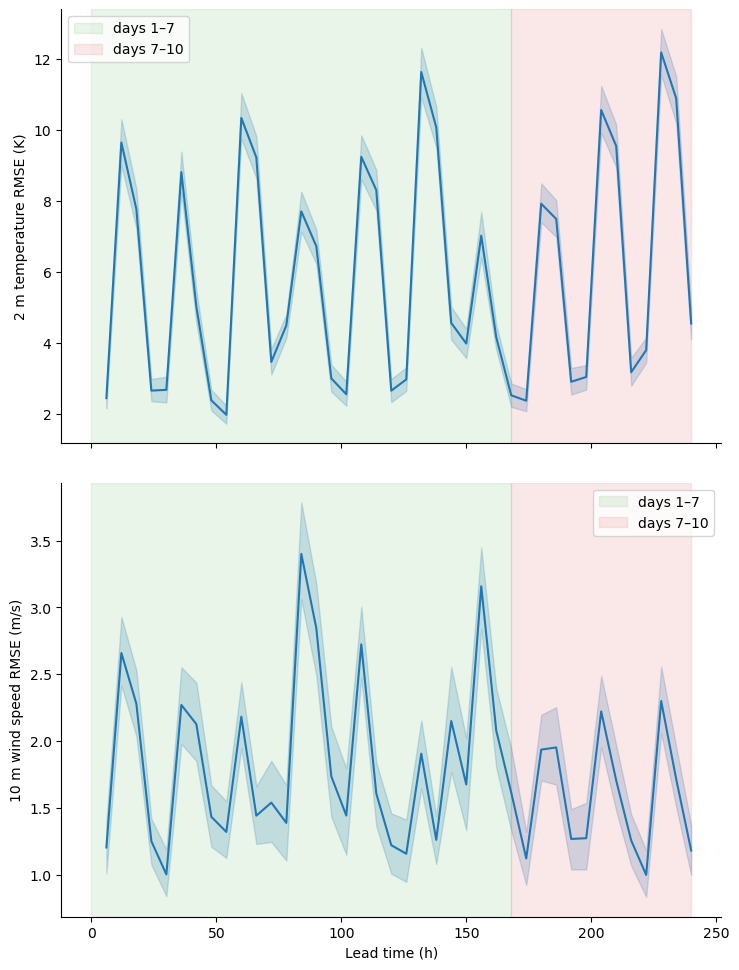

In [ ]:
# plot args
# select metric (alternatively we could do a row/col grid with var as row and metric as
# col)
metric = "rmse"
aspect = 1.5
lead_time_label = "Lead time (h)"
medium_color = sns.color_palette()[2]
extended_color = sns.color_palette()[3]
alpha = 0.1
# get long metrics data frame for seaborn
# 1. drop longitude/latitude
# 2. select target metric
# 3. reduce parallel valid_time/lead_time to lead_time only
# 4. convert to pandas data frame
plot_df = (
    metrics_ds.drop_vars(["latitude", "longitude"])
    .sel(metric=metric, drop=True)
    .isel(valid_time=xr.DataArray(range(len(metrics_ds.valid_time)), dims="valid_time"))
    .isel(valid_time=0, drop=True)
    .to_dataframe()
    .reset_index()
)
# 5. convert lead time to hours (int) and rename it for a nicer label
plot_df[lead_time_label] = (plot_df["lead_time"] / np.timedelta64(1, "h")).astype(int)
plot_df = plot_df.drop(columns=["lead_time"])
# 6. stack variables
plot_df = plot_df.melt(
    id_vars=plot_df.columns.drop(metrics_ds.data_vars), value_vars=metrics_ds.data_vars
)

# seaborn plot
g = sns.relplot(
    data=plot_df,
    x=lead_time_label,
    y="value",
    row="variable",
    # col="metric",
    kind="line",
    facet_kws=dict(sharey=False),
    aspect=aspect,
)
# tweakings
for ylabel, ax in zip(
    ["2 m temperature RMSE (K)", "10 m wind speed RMSE (m/s)"], g.axes.flat
):
    # rectangle for medium/extended ranges
    ax.axvspan(0, 7 * 24, alpha=alpha, color=medium_color, label="days 1–7")
    ax.axvspan(7 * 24, 10 * 24, alpha=alpha, color=extended_color, label="days 7–10")
    ax.legend()
    # better labels
    ax.set_ylabel(ylabel)
    ax.set_title(None)

We can also plot the AIFS 2 m temperature RMSE at each MeteoSwiss station averaged over medium/extended-range bins:

Text(0.5, 0.98, 'Station-level 2 m temperature RMSE (start: 2025-06-20 00:00:00)')

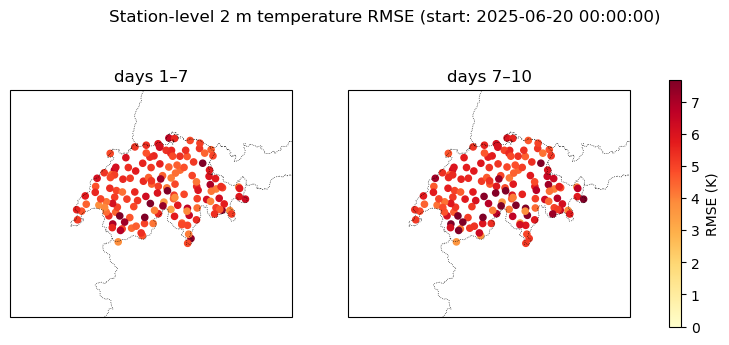

In [ ]:
bins_dict = {
    "days 1–7": (np.timedelta64(24, "h"), np.timedelta64(7 * 24, "h")),
    "days 7–10": (np.timedelta64(7 * 24, "h"), np.timedelta64(10 * 24, "h")),
}

da = xr.concat(
    [
        metrics_ds["2m_temperature"]
        .sel(metric="rmse", lead_time=slice(t0, t1))
        .mean(["lead_time", "valid_time"])
        for t0, t1 in bins_dict.values()
    ],
    dim=pd.Index(list(bins_dict.keys()), name="bin"),
).rename("RMSE (K)")

proj = ccrs.LambertConformal(central_longitude=8)
extent = [*lon_slice, *lat_slice]
norm = plt.Normalize(vmin=0, vmax=float(da.quantile(0.95)))
cmap = "YlOrRd"

fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={"projection": proj})
for ax, bin_label in zip(axes, bins_dict):
    ax.scatter(
        da.longitude.values,
        da.latitude.values,
        c=da.sel(bin=bin_label).values,
        cmap=cmap,
        norm=norm,
        s=20,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(bin_label)

fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    label="RMSE (K)",
    shrink=0.8,
)
fig.suptitle(
    f"Station-level 2 m temperature RMSE (start: {start_date.replace(tzinfo=None)})",
    # y=1.02,
)

## 8. ERA5 representativeness reference

Finally, we conclude by comparing the AIFS-station biases with the ERA5-station biases in order to assess how ERA5  reanalysis is included as a **representativeness baseline**: for each lead time the ERA5
value at the corresponding valid time is used, quantifying the irreducible gridded-to-station
interpolation error.

Data is downloaded from the [Copernicus Climate Data Store](https://cds.climate.copernicus.eu)
via `cdsapi` (skipped automatically if already done).

In [ ]:
if not era5_filepath.exists():
    tasks.era5_stationbench(start_date, lead_time, era5_filepath)
else:
    print(f"{era5_filepath} already exists; skipping")
era5_ds = xr.open_dataset(era5_filepath)
era5_ds

../data/stationbench/heatwave-2025-jun-era5.nc already exists; skipping


<xarray.Dataset> Size: 332MB
Dimensions:               (time: 1, prediction_timedelta: 40, latitude: 721,
                           longitude: 1440)
Coordinates:
  * time                  (time) datetime64[ns] 8B 2025-06-20
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 320B 06:00:0...
  * latitude              (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude             (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    2t                    (time, prediction_timedelta, latitude, longitude) float32 166MB ...
    10si                  (time, prediction_timedelta, latitude, longitude) float32 166MB ...

In [ ]:
era5_metrics = stationbench.calculate_metrics(
    forecast=era5_ds,
    stations=ts_ds,
    start_date=start_date.strftime("%Y-%m-%d"),
    end_date=end_date.strftime("%Y-%m-%d"),
    region=region,
    name_2m_temperature="2t",
    name_10m_wind_speed="10si",
)
era5_metrics

2026-03-11 16:52:32,185 - stationbench.calculate_metrics - INFO - Preparing stations data
2026-03-11 16:52:32,199 - stationbench.calculate_metrics - INFO - Selecting region: https://linestrings.com/bbox/#4.5,44.5,11.5,48.5
2026-03-11 16:52:32,260 - stationbench.calculate_metrics - INFO - Filtered stations: 157 -> 157
2026-03-11 16:52:32,584 - stationbench.calculate_metrics - INFO - Preparing forecast dataset
2026-03-11 16:52:32,642 - stationbench.calculate_metrics - INFO - Selecting region: https://linestrings.com/bbox/#4.5,44.5,11.5,48.5
2026-03-11 16:52:32,651 - stationbench.calculate_metrics - INFO - Converting longitudes from 0-360 to -180-180 range
2026-03-11 16:52:32,690 - stationbench.calculate_metrics - INFO - Renaming wind speed variable from 10si to 10m_wind_speed
2026-03-11 16:52:32,693 - stationbench.calculate_metrics - INFO - Renaming temperature variable from 2t to 2m_temperature
2026-03-11 16:52:32,696 - stationbench.calculate_metrics - INFO - Interpolating forecast to s

<xarray.Dataset> Size: 206kB
Dimensions:         (lead_time: 40, station_id: 157, metric: 2)
Coordinates:
  * lead_time       (lead_time) timedelta64[ns] 320B 0 days 06:00:00 ... 10 d...
  * station_id      (station_id) <U3 2kB 'ABO' 'AEG' 'AIG' ... 'WFJ' 'WYN' 'ZER'
    latitude        (station_id) float64 1kB 46.49 47.13 46.33 ... 47.26 46.03
    longitude       (station_id) float64 1kB 7.561 8.608 6.924 ... 7.787 7.752
  * metric          (metric) object 16B 'mbe' 'rmse'
Data variables:
    2m_temperature  (metric, lead_time, station_id) float64 100kB -3.177 ... ...
    10m_wind_speed  (metric, lead_time, station_id) float64 100kB -0.1697 ......

Text(0.5, 0.98, 'Station-level 2 m temperature MBE: AIFS vs ERA5 (start: 2025-06-20 00:00:00)')

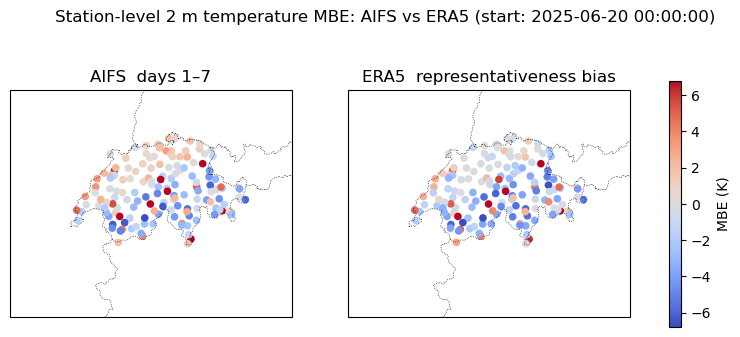

In [ ]:
aifs_bias = (
    metrics_ds["2m_temperature"]
    .sel(
        metric="mbe",
        lead_time=slice(np.timedelta64(24, "h"), np.timedelta64(7 * 24, "h")),
    )
    .mean(["lead_time", "valid_time"])
)
era5_bias = era5_metrics["2m_temperature"].sel(metric="mbe").mean("lead_time")

vlim = float(max(np.abs(aifs_bias).quantile(0.95), np.abs(era5_bias).quantile(0.95)))
cmap = "coolwarm"
norm = plt.Normalize(vmin=-vlim, vmax=vlim)

panels = [
    (aifs_bias, "AIFS  days 1–7"),
    (era5_bias, "ERA5  representativeness bias"),
]

proj = ccrs.LambertConformal(central_longitude=8)
extent = [*lon_slice, *lat_slice]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={"projection": proj})
for ax, (data, title) in zip(axes, panels):
    ax.scatter(
        metrics_ds.longitude.values,
        metrics_ds.latitude.values,
        c=data.values,
        cmap=cmap,
        norm=norm,
        s=20,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(title)

fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label="MBE (K)", shrink=0.8
)
fig.suptitle(
    "Station-level 2 m temperature MBE: AIFS vs ERA5 (start: "
    f"{start_date.replace(tzinfo=None)})"
)